# 🧠 NOTEBOOK 03 — CNN From Scratch
## Objectifs
1. Charger les données préprocessées (notebook 02)
2. **Extraire les features** avec le backbone CNN (couches convolutives)
3. **Classifier** avec la tête Dense
4. Évaluer et sauvegarder les résultats

> **Prérequis :** avoir exécuté `02_preprocessing.ipynb`

## 1. Imports & chargement de la config

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os, pickle, json
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# ─── Charger la config du notebook 02 ───────────────────────
PROC_DIR    = "../data/processed/"
OUT_MODELS  = "../outputs/models/"
OUT_PLOTS   = "../outputs/plots/"
OUT_RESULTS = "../outputs/results/"
for d in [OUT_MODELS, OUT_PLOTS, OUT_RESULTS]:
    os.makedirs(d, exist_ok=True)

with open(PROC_DIR + "config.pkl", "rb") as f:
    cfg = pickle.load(f)

IMG_SIZE   = cfg["IMG_SIZE"]
N_CLASSES  = cfg["N_CLASSES"]
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

print(f"✅ Config chargée depuis notebook 02 :")
print(f"   IMG_SIZE   = {IMG_SIZE}  → shape entrée = {INPUT_SHAPE}")
print(f"   N_CLASSES  = {N_CLASSES}")
print(f"   TF version = {tf.__version__}")


✅ Config chargée depuis notebook 02 :
   IMG_SIZE   = (96, 96)  → shape entrée = (96, 96, 3)
   N_CLASSES  = 7
   TF version = 2.20.0


## 2. Chargement des données

In [2]:
X_train = np.load(PROC_DIR + "X_train.npy")
X_val   = np.load(PROC_DIR + "X_val.npy")
X_test  = np.load(PROC_DIR + "X_test.npy")
y_train = np.load(PROC_DIR + "y_train.npy")
y_val   = np.load(PROC_DIR + "y_val.npy")
y_test  = np.load(PROC_DIR + "y_test.npy")
CLASS_NAMES = np.load(PROC_DIR + "class_names.npy", allow_pickle=True)

# Vérification critique : la shape doit correspondre à IMG_SIZE
assert X_train.shape[1:] == INPUT_SHAPE, \
    f"ERREUR : shape attendue {INPUT_SHAPE}, trouvée {X_train.shape[1:]}"

print(f"✅ Données chargées et shape vérifiée :")
print(f"   X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"   X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"   X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"   Classes : {CLASS_NAMES}")


✅ Données chargées et shape vérifiée :
   X_train : (682, 96, 96, 3)  y_train : (682,)
   X_val   : (158, 96, 96, 3)    y_val   : (158,)
   X_test  : (210, 96, 96, 3)   y_test  : (210,)
   Classes : ['Baby Care' 'Beauty and Personal Care' 'Computers'
 'Home Decor & Festive Needs' 'Home Furnishing' 'Kitchen & Dining'
 'Watches']


## 3. Architecture CNN From Scratch

```
Input (96×96×3)
  ↓
[Block 1] Conv2D(32,3x3) → Conv2D(32,3x3) → BN → ReLU → MaxPool(2) → Dropout(0.25)
  ↓
[Block 2] Conv2D(64,3x3) → Conv2D(64,3x3) → BN → ReLU → MaxPool(2) → Dropout(0.25)
  ↓
[Block 3] Conv2D(128,3x3)→ Conv2D(128,3x3)→ BN → ReLU → MaxPool(2) → Dropout(0.25)
  ↓
GlobalAveragePooling2D   ← extraction de features (vecteur 128-dim)
  ↓
Dense(256, relu) → Dropout(0.5)
  ↓
Dense(N_classes, softmax)
```

In [3]:
def build_cnn_scratch(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape, name="input_image")
    
    # ── EXTRACTION DE FEATURES (backbone) ──────────────────
    # Block 1
    x = layers.Conv2D(32, (3,3), padding="same")(inputs)
    x = layers.Conv2D(32, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)          # 96 → 48
    x = layers.Dropout(0.25)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)          # 48 → 24
    x = layers.Dropout(0.25)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)          # 24 → 12
    x = layers.Dropout(0.25)(x)
    
    # GlobalAvgPool → vecteur de features (pas de Flatten = moins d'overfitting)
    features = layers.GlobalAveragePooling2D(name="feature_vector")(x)
    
    # ── TÊTE DE CLASSIFICATION ──────────────────────────────
    x = layers.Dense(256, activation="relu")(features)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)
    
    model = keras.Model(inputs, outputs, name="CNN_Scratch")
    return model

model = build_cnn_scratch(INPUT_SHAPE, N_CLASSES)
model.summary()


Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector                  │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │         1,79

 Total params: 322,727 (1.23 MB)

 Trainable params: 322,279 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Data Augmentation

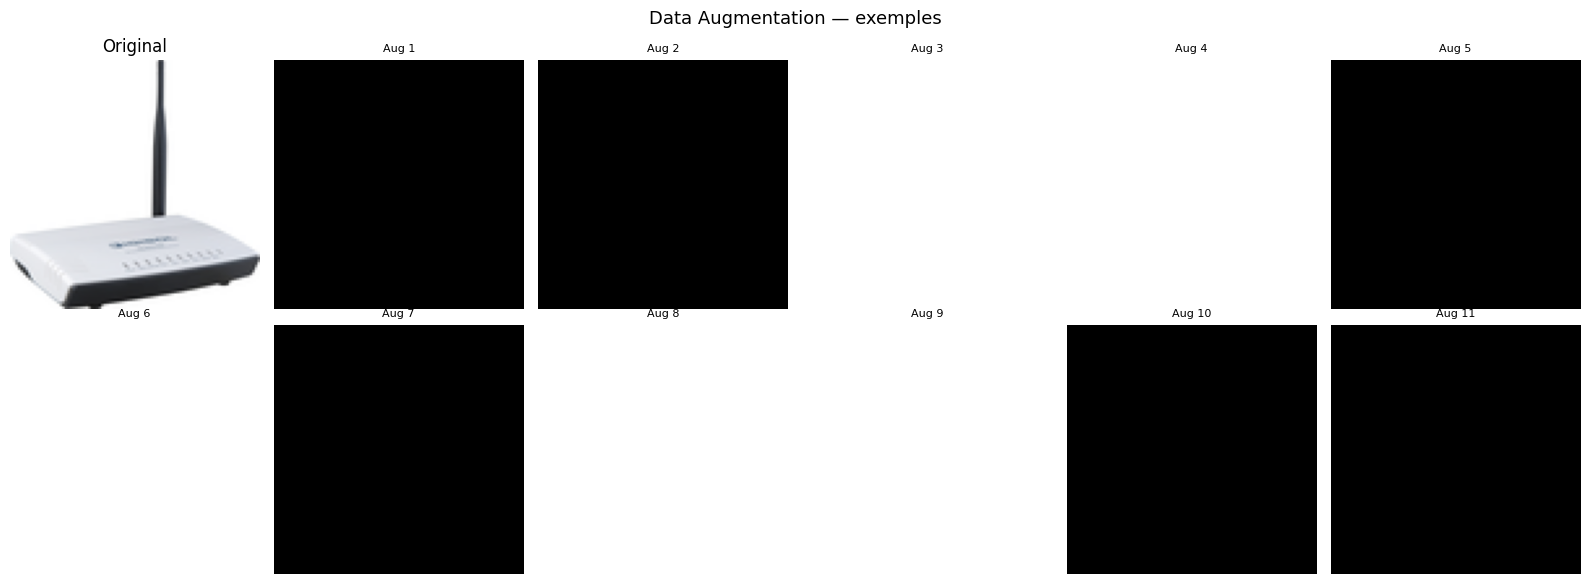

In [4]:
# Augmentation UNIQUEMENT sur le train, désactivée en val/test
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(factor=0.1),
], name="data_augmentation")

# Visualiser l'effet de l'augmentation
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Data Augmentation — exemples", fontsize=13)
axes[0][0].imshow(X_train[0]); axes[0][0].set_title("Original"); axes[0][0].axis("off")
sample = tf.expand_dims(X_train[0], 0)
for i in range(1, 12):
    r, c = divmod(i, 6)
    aug = data_aug(sample, training=True)[0].numpy()
    axes[r][c].imshow(np.clip(aug, 0, 1))
    axes[r][c].set_title(f"Aug {i}", fontsize=8)
    axes[r][c].axis("off")
plt.tight_layout()
plt.savefig(OUT_PLOTS + "03_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Entraînement

In [5]:
# ── Pipeline tf.data ────────────────────────────────────────
def augment_fn(x, y): return data_aug(x, training=True), y

BATCH = 32

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2000, seed=42)
            .batch(BATCH)
            .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH)
          .prefetch(tf.data.AUTOTUNE))

# ── Compilation ─────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # labels entiers (pas one-hot)
    metrics=["accuracy"]
)

# ── Callbacks ───────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        OUT_MODELS + "cnn_scratch.keras",
        monitor="val_accuracy", save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5,
        min_lr=1e-6, verbose=1),
]

print("🚀 Entraînement du CNN Scratch...")
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=80, callbacks=callbacks, verbose=1
)
print(f"\n✅ Meilleure val_accuracy : {max(history.history['val_accuracy'])*100:.2f}%")


🚀 Entraînement du CNN Scratch...
Epoch 1/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1146 - loss: 2.3128
Epoch 1: val_accuracy improved from None to 0.13924, saving model to ../outputs/models/cnn_scratch.keras

Epoch 1: finished saving model to ../outputs/models/cnn_scratch.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1202 - loss: 2.2450 - val_accuracy: 0.1392 - val_loss: 1.9555 - learning_rate: 0.0010
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1476 - loss: 2.0752
Epoch 2: val_accuracy did not improve from 0.13924
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.1144 - loss: 2.0756 - val_accuracy: 0.1392 - val_loss: 1.9533 - learning_rate: 0.0010
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1162 - loss: 2.0205
Epoch 3: val_accuracy did not improve from 0.13924
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1246 - loss: 2.0124 - val_accuracy: 0.1392 - val_loss: 1.9548 - learning_rate: 0.0010
Epoch 4/80
22/22 ━━━━━━

## 6. Courbes d'entraînement

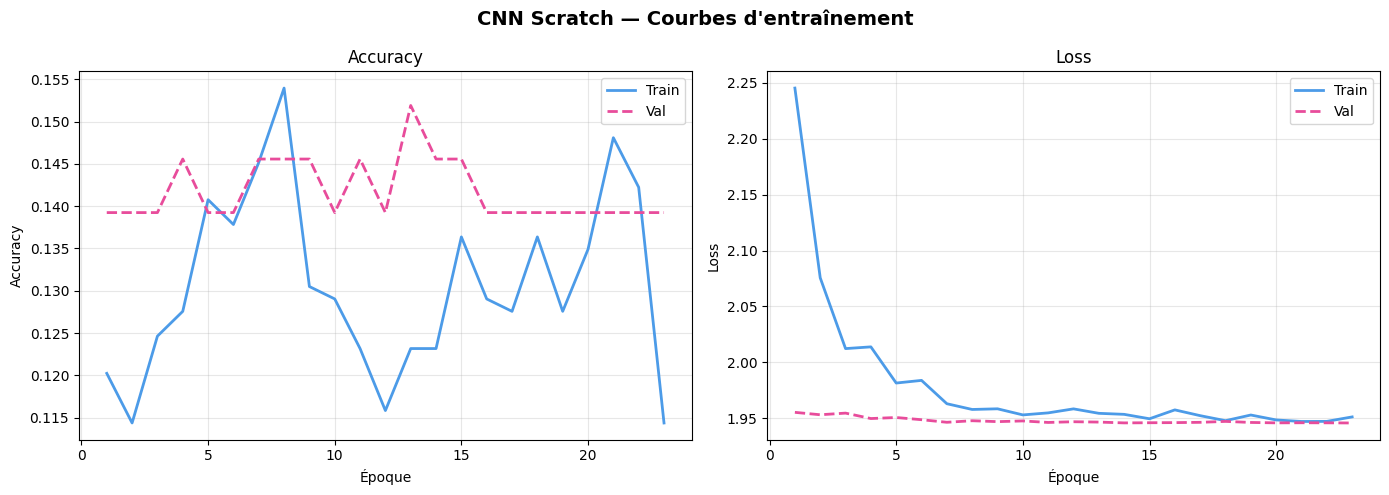

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Scratch — Courbes d'entraînement", fontsize=14, fontweight="bold")

ep = range(1, len(history.history["accuracy"])+1)
axes[0].plot(ep, history.history["accuracy"],     label="Train",  color="#4C9BE8", lw=2)
axes[0].plot(ep, history.history["val_accuracy"], label="Val",    color="#E84C9B", lw=2, ls="--")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Accuracy")

axes[1].plot(ep, history.history["loss"],     label="Train", color="#4C9BE8", lw=2)
axes[1].plot(ep, history.history["val_loss"], label="Val",   color="#E84C9B", lw=2, ls="--")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig(OUT_PLOTS + "03_curves_cnn_scratch.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Évaluation sur le Test Set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Test Accuracy : 15.24%
Test Loss     : 1.9468

                            precision    recall  f1-score   support

                 Baby Care       0.00      0.00      0.00        30
  Beauty and Personal Care       0.00      0.00      0.00        30
                 Computers       0.00      0.00      0.00        30
Home Decor & Festive Needs       0.15      0.93      0.25        30
           Home Furnishing       0.22      0.13      0.17        30
          Kitchen & Dining       0.00      0.00      0.00        30
                   Watches       0.00      0.00      0.00        30

                  accuracy                           0.15       210
                 macro avg       0.05      0.15      0.06       210
              weighted avg       0.05      0.15      0.06       210



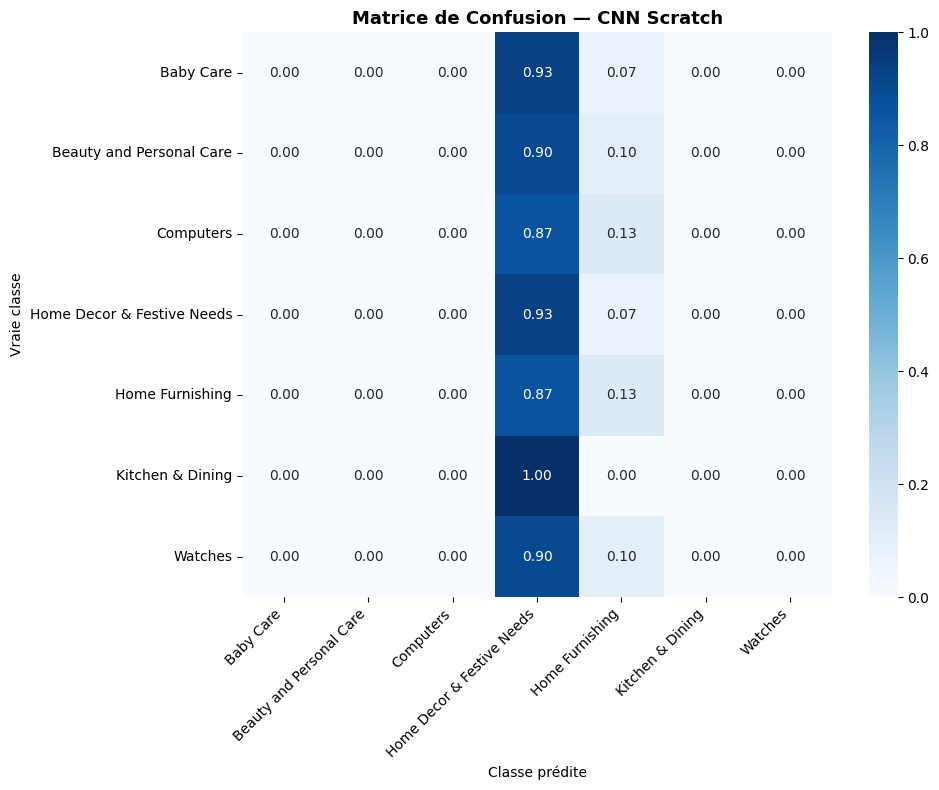

In [8]:
# Matrice de confusion
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Matrice de Confusion — CNN Scratch", fontsize=13, fontweight="bold")
ax.set_ylabel("Vraie classe"); ax.set_xlabel("Classe prédite")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_PLOTS + "03_cm_cnn_scratch.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Extraction de features (vecteur intermédiaire)

In [9]:
# Modèle qui s'arrête à GlobalAvgPool → vecteur de features par image
feature_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer("feature_vector").output,
    name    = "cnn_scratch_feature_extractor"
)

features_train = feature_extractor.predict(X_train, batch_size=32, verbose=1)
features_val   = feature_extractor.predict(X_val,   batch_size=32, verbose=0)
features_test  = feature_extractor.predict(X_test,  batch_size=32, verbose=0)

print(f"\nShape des features extraites :")
print(f"  Train : {features_train.shape}  ← {features_train.shape[1]}-dim par image")
print(f"  Val   : {features_val.shape}")
print(f"  Test  : {features_test.shape}")

# Sauvegarder les features extraites
np.save(PROC_DIR + "features_train_cnn.npy", features_train)
np.save(PROC_DIR + "features_val_cnn.npy",   features_val)
np.save(PROC_DIR + "features_test_cnn.npy",  features_test)
print("\n💾 Features sauvegardées dans data/processed/")


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step

Shape des features extraites :
  Train : (682, 128)  ← 128-dim par image
  Val   : (158, 128)
  Test  : (210, 128)

💾 Features sauvegardées dans data/processed/


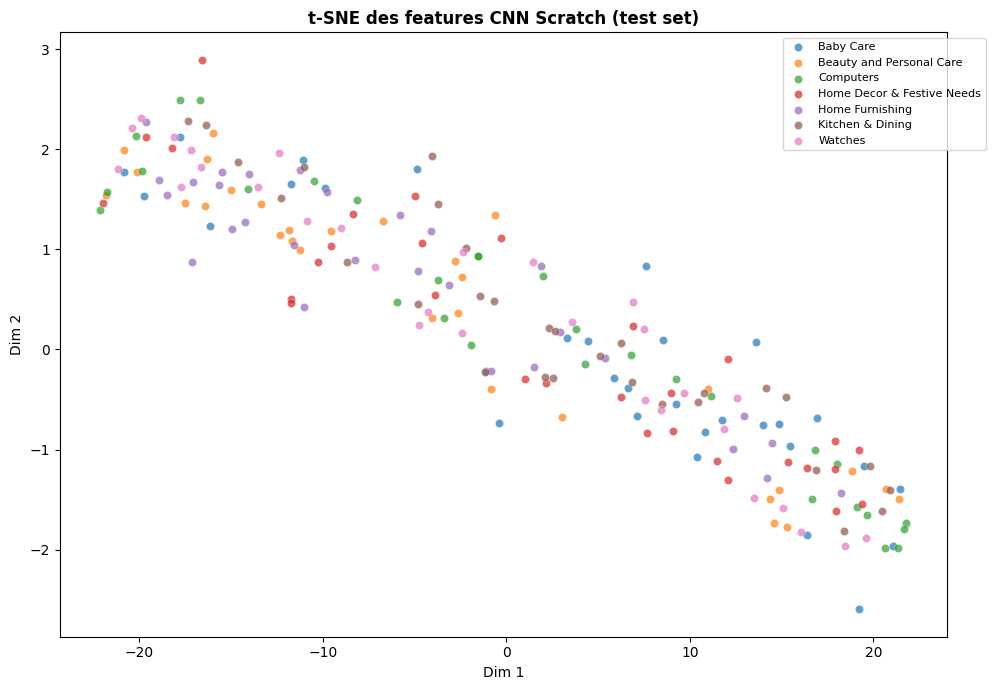

In [11]:
# Visualiser les features avec t-SNE (projection 2D)
from sklearn.manifold import TSNE

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb    = tsne.fit_transform(features_test)

fig, ax = plt.subplots(figsize=(10, 7))
palette = plt.cm.tab10.colors
for cls_idx in range(N_CLASSES):
    mask = (y_test == cls_idx)
    ax.scatter(emb[mask, 0], emb[mask, 1],
               label=CLASS_NAMES[cls_idx], alpha=0.7,
               color=palette[cls_idx], s=35, edgecolors="white", linewidths=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_title("t-SNE des features CNN Scratch (test set)", fontsize=12, fontweight="bold")
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
plt.tight_layout()
plt.savefig(OUT_PLOTS + "03_tsne_cnn_scratch.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Sauvegarde des résultats

In [12]:
results_cnn = {
    "model":     "CNN (scratch)",
    "accuracy":  round(float(test_acc), 4),
    "f1_score":  round(float(f1_score(y_test, y_pred, average="weighted")), 4),
    "history": {
        "accuracy":     [float(v) for v in history.history["accuracy"]],
        "val_accuracy": [float(v) for v in history.history["val_accuracy"]],
        "loss":         [float(v) for v in history.history["loss"]],
        "val_loss":     [float(v) for v in history.history["val_loss"]],
    }
}
with open(OUT_RESULTS + "results_cnn_scratch.json", "w") as f:
    json.dump(results_cnn, f, indent=2)

print("="*55)
print("  ✅ NOTEBOOK 03 TERMINÉ — CNN Scratch")
print("="*55)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  F1-Score      : {results_cnn['f1_score']*100:.2f}%")
print()
print("  Fichiers sauvegardés :")
print("    outputs/models/cnn_scratch.keras")
print("    outputs/plots/03_curves_cnn_scratch.png")
print("    outputs/plots/03_cm_cnn_scratch.png")
print("    outputs/plots/03_tsne_cnn_scratch.png")
print("    outputs/results/results_cnn_scratch.json")
print("    data/processed/features_*_cnn.npy")
print()
print("→ Exécuter ensuite : 04_resnet50.ipynb")


  ✅ NOTEBOOK 03 TERMINÉ — CNN Scratch
  Test Accuracy : 15.24%
  F1-Score      : 5.98%

  Fichiers sauvegardés :
    outputs/models/cnn_scratch.keras
    outputs/plots/03_curves_cnn_scratch.png
    outputs/plots/03_cm_cnn_scratch.png
    outputs/plots/03_tsne_cnn_scratch.png
    outputs/results/results_cnn_scratch.json
    data/processed/features_*_cnn.npy

→ Exécuter ensuite : 04_resnet50.ipynb
